# 01 — Exploración y preparación de datos

## Objetivo

Explorar una serie histórica financiera, validar su calidad y
transformarla en una serie de rendimientos adecuada para el
modelado posterior.

## Fuente

S&P 500 (`SP500`) — FRED, Federal Reserve Bank of St. Louis.

La serie representa el valor diario del índice S&P 500 al cierre.

## Alcance

En esta etapa no se realizan simulaciones Monte Carlo.

El objetivo es obtener datos históricos limpios y parámetros
estadísticos que posteriormente serán utilizados por el modelo
de escenarios.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

PROJECT_ROOT:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo


In [9]:
from src.data.loader import load_csv

from src.data.preprocessing import (
    prepare_price_data,
    calculate_log_returns,
)

from src.visualization.plots import (
    plot_price_series,
    plot_returns,
)

print("Módulos del proyecto importados correctamente.")

Módulos del proyecto importados correctamente.


In [10]:
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "sp500.csv"
)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

print("Dataset original:")
print(RAW_DATA_PATH)

print("\nDataset procesado:")
print(PROCESSED_DATA_PATH)

Dataset original:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\data\raw\sp500.csv

Dataset procesado:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\data\processed\sp500_returns.csv


In [11]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset:\n{RAW_DATA_PATH}"
    )

print("Dataset encontrado correctamente.")

Dataset encontrado correctamente.


In [12]:
raw_data = load_csv(RAW_DATA_PATH)

print("Filas:", len(raw_data))
print("Columnas:", list(raw_data.columns))

Filas: 1305
Columnas: ['observation_date', 'SP500']


In [13]:
raw_data.head()

,observation_date,SP500
0,2021-08-23,4479.53
1,2021-08-24,4486.23
2,2021-08-25,4496.19
3,2021-08-26,4470.00
4,2021-08-27,4509.37


In [14]:
raw_data.tail()

,observation_date,SP500
1300,2026-08-17,7745.06
1301,2026-08-18,7691.76
1302,2026-08-19,7707.98
1303,2026-08-20,7641.16
1304,2026-08-21,7674.37


In [15]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1305 non-null   str    
 1   SP500             1255 non-null   float64
dtypes: float64(1), str(1)
memory usage: 20.5 KB


In [16]:
raw_data.describe()

,SP500
count,1255.000000
mean,5249.664351
std,1124.519636
min,3577.030000
25%,4305.730000
50%,5010.600000
75%,6051.610000
max,7798.990000


In [17]:
missing_values = raw_data.isna().sum()

missing_values

observation_date     0
SP500               50
dtype: int64

In [18]:
duplicate_rows = raw_data.duplicated().sum()

print("Filas duplicadas:", duplicate_rows)

Filas duplicadas: 0


In [19]:
price_data = prepare_price_data(
    raw_data,
    date_column="observation_date",
    price_column="SP500",
)

price_data.head()

,observation_date,SP500
0,2021-08-23,4479.53
1,2021-08-24,4486.23
2,2021-08-25,4496.19
3,2021-08-26,4470.00
4,2021-08-27,4509.37


In [20]:
print("Filas:", len(price_data))
print("Columnas:", list(price_data.columns))

Filas: 1255
Columnas: ['observation_date', 'SP500']


In [21]:
print(
    "Fecha inicial:",
    price_data["observation_date"].min(),
)

print(
    "Fecha final:",
    price_data["observation_date"].max(),
)

Fecha inicial: 2021-08-23 00:00:00
Fecha final: 2026-08-21 00:00:00


In [22]:
is_sorted = (
    price_data["observation_date"]
    .is_monotonic_increasing
)

print("Serie ordenada cronológicamente:", is_sorted)

Serie ordenada cronológicamente: True


In [23]:
print(
    price_data.isna().sum()
)

observation_date    0
SP500               0
dtype: int64


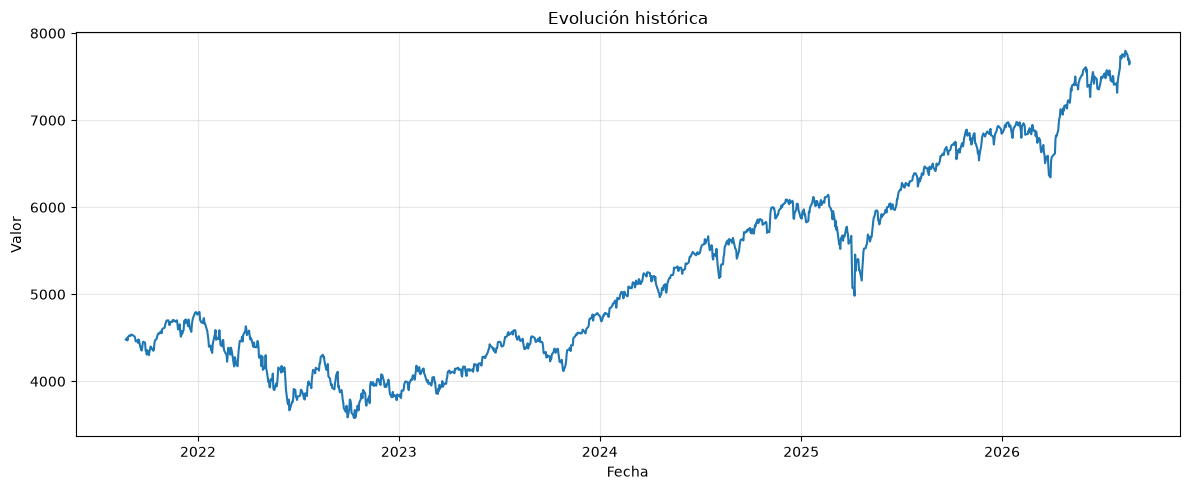

In [24]:
plot_price_series(
    price_data,
    date_column="observation_date",
    price_column="SP500",
)

In [25]:
returns_data = calculate_log_returns(
    price_data,
    price_column="SP500",
)

returns_data.head()

,observation_date,SP500,log_return
0,2021-08-24,4486.23,0.001495
1,2021-08-25,4496.19,0.002218
2,2021-08-26,4470.00,-0.005842
3,2021-08-27,4509.37,0.008769
4,2021-08-30,4528.79,0.004297


In [26]:
print("Filas:", len(returns_data))
print("Columnas:", list(returns_data.columns))

Filas: 1254
Columnas: ['observation_date', 'SP500', 'log_return']


In [27]:
returns_data["log_return"].describe()

count    1254.000000
mean        0.000429
std         0.010722
min        -0.061609
25%        -0.004795
50%         0.000710
75%         0.006198
max         0.090895
Name: log_return, dtype: float64